## Generating artwork with cellular automata

![](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

[Growing Cellular Automata - A Differentiable Model of Morphogenesis](https://distill.pub/2020/growing-ca/) was published on [distill.pub](distill.pub) in 2020. 

Cellular automata as an idea were formulated by Von Neumann and Stanislaw Ulam in 1940. Conway used it as a way to analyze Turing-complete state machines, but it soon became a form of mathematical art. Now that we've got differentiable cellular automata, we can add our own art to the list. 

Let's examine the techniques in *Growing Cellular Automata* and replicate them in Pytorch.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import warnings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not torch.cuda.is_available():
    warnings.warn("CUDA is not available. Using CPU.")

/home/will/miniconda3/envs/cellularimages/lib/python3.11/site-packages/torch/_subclasses/functional_tensor.py:276: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:81.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


## Step 1: Defining our map

Unlike Conway's game of life, our map isn't a grid of binary states. To have each element in our map be a pixel with arbitrary RGB values, our map has to be a tensor of at least shape (width, height, 3). 

Each cell also updates based on a function of its eight closest neighbors, and in practice, is shape (width, height, D). The vector $\in \mathbb{R}^D$ for each cell has its first 3 dims represent the RGB values of the cell, the 4th dim representing the $\alpha$ (transparency) value of the cell, and the 5th-D dims representing hidden information that the cell can propagate to its neighbors with each tick. 

Last dim of each cell: [R, G, B, $\alpha$, hidden_info_dims]

In [9]:
import dataclasses
from torchinfo import summary as torchinfo_summary

@dataclasses.dataclass
class ModelParams:
    update_blocks: int = 2

@dataclasses.dataclass
class CellAutomataParams:
    min_steps: int = 0
    max_steps: int = 0
    min_backprop_steps: int = 64 # the number of backprop steps we take is randomly sampled from [min, max]
    max_backprop_steps: int = 96 # too many and you might run out of memory!
    map_width: int = 48
    map_height: int = 60
    cell_channels: int = 32 # D, as explained above
    perception_size: tuple = (3,3) # defines the size of the neighboring region that the cell updates from
    alive_threshold: float = 0.1 # a cell is dead if its alpha < this threshold - allows for some computation saving
    model_params: ModelParams = dataclasses.field(default_factory=ModelParams)

class MapFN(nn.Module):
    def __init__(self, params: CellAutomataParams):
        super(MapFN, self).__init__()
        self.params = params

        self.cell_perception = nn.Conv2d(
            in_channels=params.cell_channels,
            out_channels=params.cell_channels,
            kernel_size=params.perception_size,
            padding=params.perception_size[0] // 2,  # same padding
        )
        
        self.activation = nn.SiLU()
        self.update_blocks = nn.ModuleList([
            nn.Linear(
                in_features=params.cell_channels,
                out_features=params.cell_channels,
            )
            for _ in range(params.model_params.update_blocks)
        ])

        # zero-initialize the residual linear layers to avoid initial explosion
        for block in self.update_blocks:
            block.weight.data.zero_()
            block.bias.data.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert (self.params.map_height, self.params.map_width, self.params.cell_channels) == (
            x.shape[1], x.shape[2], x.shape[3]
        ), "Input shape mismatch: should be (B, H, W, C)"
        x = x.permute(0, 3, 1, 2) # (B, H, W, C) -> (B, C, H, W)

        x = self.cell_perception(x)
        x = self.activation(x)
        x = x.permute(0, 2, 3, 1) # (B, C, H, W) -> (B, H, W, C)
        for update_block in self.update_blocks:
            residual = x
            x = update_block(x)
            x = self.activation(x) + residual

        return x

# Visualize model
params = CellAutomataParams()
model = MapFN(params)
torchinfo_summary(model, input_size=(1, params.map_height, params.map_width, params.cell_channels))

Layer (type:depth-idx)                   Output Shape              Param #
MapFN                                    [1, 60, 48, 32]           --
├─Conv2d: 1-1                            [1, 32, 60, 48]           9,248
├─SiLU: 1-2                              [1, 32, 60, 48]           --
├─ModuleList: 1-5                        --                        (recursive)
│    └─Linear: 2-1                       [1, 60, 48, 32]           1,056
├─SiLU: 1-4                              [1, 60, 48, 32]           --
├─ModuleList: 1-5                        --                        (recursive)
│    └─Linear: 2-2                       [1, 60, 48, 32]           1,056
├─SiLU: 1-6                              [1, 60, 48, 32]           --
Total params: 11,360
Trainable params: 11,360
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 26.64
Input size (MB): 0.37
Forward/backward pass size (MB): 2.21
Params size (MB): 0.05
Estimated Total Size (MB): 2.63

This model is fairly lightweight - which is good, because the final deployment platform is the browser. 

Let's train our cellular automata to arrange themselves into the shape of the Terminator - although perhaps the T-1000 would be the more fitting image to use.

### Utility script:

In [ ]:
#!wget "https://cdn.vox-cdn.com/thumbor/9nbXok5OoYQn59zohWeVrW7C814=/0x0:1020x680/2000x1333/filters:focal(496x288:497x289)/cdn2.vox-cdn.com/assets/4658579/terminator_endoskeleton_1020.jpg"
#!mv terminator_endoskeleton_1020.jpg target.jpg
!mv terminator_endoskeleton_1020-removebg-preview.png target.jpg

In [39]:
from skimage import io
from skimage import transform
import matplotlib.pyplot as plt
from skimage.transform import resize
import numpy as np

cropped = io.imread("../target_images/terminator-removebg-preview.png") / 255.0
cropped = resize(cropped, (64, 96),
                       anti_aliasing=True)
cropped = cropped[:-12,24:-24]
# If no background:
# cropped = np.concatenate([cropped, np.ones((cropped.shape[0], cropped.shape[1], 1))], axis = 2)
cropped = cropped * (cropped[:, :, 2] < 1)[:, :, np.newaxis]
cropped = np.pad(cropped, ((4, 4), (0, 0), (0,0)), mode='constant')

xx, yy = np.mgrid[:cropped.shape[0], :cropped.shape[1]]
center_coords = (22, 28)
radius = 24
circle = ((yy - center_coords[0]) ** 2 + (xx - center_coords[1]) ** 2) < radius**2

cropped = cropped * circle[:,:,np.newaxis]

from PIL import Image

Image.fromarray((cropped * 255).astype(np.uint8)).save("target_image.png")
print("Image shape:", cropped.shape)

Image shape: (60, 48, 4)


## Model Training:

Image shape: (60, 48, 4)


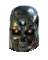

In [43]:
from PIL import Image
import os
import numpy as np

TARGET_DIR = "../target_images"
im = Image.open(os.path.join(TARGET_DIR, "terminator.png")) # Feel free to replace this with your own
tensor_data = np.array(im)

print(f"Image shape: {tensor_data.shape}")
im

In [ ]:
from tqdm import tqdm, trange
from collections import defaultdict
import random

EPOCHS = 1001
history = []
SAMPLE_EVERY = 50
BATCH_SIZE = 32
REPLACE_RATE = 0.2
POOL_SIZE = 1024

seed = np.zeros((HYPERPARAMS['map_height'], HYPERPARAMS['map_width'], HYPERPARAMS['cell_vars']))
seed[HYPERPARAMS['map_height']//2][HYPERPARAMS['map_width']//2][3:] += 1 # Alive cell in the middle of the image
pool = [[i, -float('inf'), np.copy(seed)] for i in range(POOL_SIZE)]

with trange(EPOCHS) as pbar:
    for epoch in pbar:
        batch = random.sample(pool, BATCH_SIZE)
        grid = tf.convert_to_tensor(np.array([i[2] for i in batch]), dtype=tf.float32)

        if epoch % SAMPLE_EVERY == 0: history.append([grid[:, :, :, :3].numpy()])
        n_backprop_steps = random.randint(HYPERPARAMS['min-backprop-steps'],HYPERPARAMS['max-backprop-steps'])
        n_steps = random.randint(HYPERPARAMS['min-steps'], HYPERPARAMS['max-steps'])
        for ep in range(max(0, n_steps - n_backprop_steps)):
            grid += update_grid_batch(grid)
            #grid = tf.clip_by_value(grid, 0, 1)
            if epoch % SAMPLE_EVERY == 0: history[-1].append(grid[:, :, :4].numpy())
        with tf.GradientTape() as grad:
            grad.watch(grid); grad.watch(update_model.trainable_variables)
            for ep in range(n_backprop_steps):
                update_batch = update_grid_batch(grid)
                grid = grid + update_batch
                #grid = tf.clip_by_value(grid, 0, 1)
                if epoch % SAMPLE_EVERY == 0: history[-1].append(grid[:, :, :4].numpy())

            # dGdP = [tf.reduce_sum(tf.stack(grads_per_step[key]), axis=1) for key in grads_per_step]
            grad.watch(cropped)
            L = loss(grid[:, :, :, :4], cropped)
            reduced_loss = tf.reduce_mean(L)
        
        dLdP = grad.gradient(reduced_loss, update_model.trainable_variables)
        batch_losses = L.numpy()
        pool_idxs = [i[0] for i in batch]
        for index, i in enumerate(pool_idxs):
            pool[i][1] = batch_losses[index]
            pool[i][2] = grid[index]
        pool = sorted(pool, key = lambda x: x[1])
        for i in range(1, round(REPLACE_RATE*BATCH_SIZE)+1):
            pool[-i][1] = -float('inf'); pool[-i][2] = np.copy(seed) # Replace highest loss item in the pool with the new seed.
        """
            with tf.GradientTape() as grad:
                grad.watch(grid); grad.watch(cropped)
                L = loss(grid[:,:,:3], cropped)
            dLdG = grad.gradient(L, grid)
        """
        normed_grads = [g/(tf.norm(g)+1e-8) for g in dLdP]
        optimizer.apply_gradients(zip(normed_grads, update_model.trainable_weights))
        
        pbar.set_description("Loss: {0:.5f}".format(reduced_loss.numpy()), refresh = True)